# Model Evaluation
### This notebook runs the COCO evaluation tool and prints out accuracy metrics pertaining to bounding box accuracy and/or segmentation accuracy. 

## Import dependencies

In [1]:
# COCO related libraries
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from pycocotools import mask as maskUtils
from samples.coco import coco
from samples.coco.coco import evaluate_coco

# MaskRCNN libraries
import mrcnn.model as modellib
import mrcnn.utils as utils
import mrcnn.visualize as visualize

# Misc
import os
import skimage.io
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tnrange, tqdm_notebook
%matplotlib inline 

/home/venv/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/venv/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/venv/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/venv/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:519: FutureWarning: Passing (type, 1) or 

## Constants

In [6]:
# Number of classes in dataset. Must be of type integer
NUM_CLASSES = 5

# Relative path to .h5 weights file
WEIGHTS_FILE = 'logs/resnetxt152_trial20220615T0538/mask_rcnn_resnetxt152_trial_0100.h5'

# Relative path to ground truth annotations JSON file
GT_ANNOTATIONS_FILE = 'datasets/dataset_cells/test/V2_test_annotations.json'

# Relative path to images associated with ground truth JSON file
DATASET_DIR = 'datasets/dataset_cells/test/'

MODEL_NAME = '152_test_model'


## Additional Setup

In [7]:
# Set the ROOT_DIR variable to the root directory of the Mask_RCNN git repo
ROOT_DIR = os.getcwd()

# Directory to save logs and trained model
MODEL_DIR = os.path.join(ROOT_DIR, "logs")

# Select which GPU to use
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID";
os.environ["CUDA_VISIBLE_DEVICES"]="0"; 

## Declare evaluation configuration

In [8]:
class EvalConfig(coco.CocoConfig):
    """ Configuration for evaluation """
    
    # How many GPUs
    GPU_COUNT = 1
    
    # How many images per gpu
    IMAGES_PER_GPU = 1

    # Number of classes (including background)
    NUM_CLASSES = 1 + NUM_CLASSES  # background + other classes
    
    IMAGE_MIN_DIM = 1152
    IMAGE_MAX_DIM = 1280
    
    # Matterport originally used resnet101, but I downsized to fit it on my graphics card
    BACKBONE = 'resnetxt152'

    # To be honest, I haven't taken the time to figure out what these do
    RPN_ANCHOR_SCALES = (32, 64, 128, 256, 512)
    
    # Changed to 512 because that's how many the original MaskRCNN paper used
    TRAIN_ROIS_PER_IMAGE = 200
    MAX_GT_INSTANCES = 114
    POST_NMS_ROIS_INFERENCE = 1000 
    POST_NMS_ROIS_TRAINING = 2000 
    
    DETECTION_MAX_INSTANCES = 114
    DETECTION_MIN_CONFIDENCE = 0.8

## Display configuration

In [9]:
EvalConfig().display()


Configurations:
BACKBONE                       resnetxt152
BACKBONE_STRIDES               [4, 8, 16, 32, 64]
BATCH_SIZE                     1
BBOX_STD_DEV                   [0.1 0.1 0.2 0.2]
COMPUTE_BACKBONE_SHAPE         None
DETECTION_MAX_INSTANCES        114
DETECTION_MIN_CONFIDENCE       0.8
DETECTION_NMS_THRESHOLD        0.3
FPN_CLASSIF_FC_LAYERS_SIZE     1024
GPU_COUNT                      1
GRADIENT_CLIP_NORM             5.0
IMAGES_PER_GPU                 1
IMAGE_CHANNEL_COUNT            3
IMAGE_MAX_DIM                  1280
IMAGE_META_SIZE                18
IMAGE_MIN_DIM                  1152
IMAGE_MIN_SCALE                0
IMAGE_RESIZE_MODE              square
IMAGE_SHAPE                    [1280 1280    3]
LEARNING_MOMENTUM              0.9
LEARNING_RATE                  0.001
LOSS_WEIGHTS                   {'rpn_class_loss': 1.0, 'rpn_bbox_loss': 1.0, 'mrcnn_class_loss': 1.0, 'mrcnn_bbox_loss': 1.0, 'mrcnn_mask_loss': 1.0}
MASK_POOL_SIZE                 14
MASK_SHAPE      

## Build class to load ground truth data

In [10]:
class CocoDataset(utils.Dataset):
    def load_coco_gt(self, annotations_file, dataset_dir):
        """Load a COCO styled ground truth dataset
        """
        
        # Create COCO object
        coco = COCO(annotations_file)

        # Load all classes
        class_ids = sorted(coco.getCatIds())

        # Load all images
        image_ids = list(coco.imgs.keys())

        # Add classes
        for i in class_ids:
            self.add_class("coco", i, coco.loadCats(i)[0]["name"])

        # Add images
        for i in image_ids:
            self.add_image(
                "coco", image_id = i,
                path = os.path.join(dataset_dir, coco.imgs[i]['file_name']),
                width = coco.imgs[i]["width"],
                height = coco.imgs[i]["height"],
                annotations = coco.loadAnns(coco.getAnnIds(
                    imgIds = [i], catIds = class_ids, iscrowd=None)))
        
        return coco
    
    def load_mask(self, image_id):
        """Load instance masks for the given image.
        Different datasets use different ways to store masks. This
        function converts the different mask format to one format
        in the form of a bitmap [height, width, instances].
        Returns:
        masks: A bool array of shape [height, width, instance count] with
            one mask per instance.
        class_ids: a 1D array of class IDs of the instance masks.
        """
        # If not a COCO image, delegate to parent class.
        image_info = self.image_info[image_id]
        if image_info["source"] != "coco":
            return super(CocoDataset, self).load_mask(image_id)

        instance_masks = []
        class_ids = []
        annotations = self.image_info[image_id]["annotations"]
        # Build mask of shape [height, width, instance_count] and list
        # of class IDs that correspond to each channel of the mask.
        for annotation in annotations:
            class_id = self.map_source_class_id(
                "coco.{}".format(annotation['category_id']))
            if class_id:
                m = self.annToMask(annotation, image_info["height"],
                                   image_info["width"])
                # Some objects are so small that they're less than 1 pixel area
                # and end up rounded out. Skip those objects.
                if m.max() < 1:
                    continue
                # Is it a crowd? If so, use a negative class ID.
                if annotation['iscrowd']:
                    # Use negative class ID for crowds
                    class_id *= -1
                    # For crowd masks, annToMask() sometimes returns a mask
                    # smaller than the given dimensions. If so, resize it.
                    if m.shape[0] != image_info["height"] or m.shape[1] != image_info["width"]:
                        m = np.ones([image_info["height"], image_info["width"]], dtype=bool)
                instance_masks.append(m)
                class_ids.append(class_id)

        # Pack instance masks into an array
        if class_ids:
            mask = np.stack(instance_masks, axis=2).astype(np.bool)
            class_ids = np.array(class_ids, dtype=np.int32)
            return mask, class_ids
        else:
            # Call super class to return an empty mask
            return super(CocoDataset, self).load_mask(image_id)

    def image_reference(self, image_id):
        """Return a link to the image in the COCO Website."""
        info = self.image_info[image_id]
        if info["source"] == "coco":
            return "http://cocodataset.org/#explore?id={}".format(info["id"])
        else:
            super(CocoDataset, self).image_reference(image_id)

    # The following two functions are from pycocotools with a few changes.

    def annToRLE(self, ann, height, width):
        """
        Convert annotation which can be polygons, uncompressed RLE to RLE.
        :return: binary mask (numpy 2D array)
        """
        segm = ann['segmentation']
        if isinstance(segm, list):
            # polygon -- a single object might consist of multiple parts
            # we merge all parts into one mask rle code
            rles = maskUtils.frPyObjects(segm, height, width)
            rle = maskUtils.merge(rles)
        elif isinstance(segm['counts'], list):
            # uncompressed RLE
            rle = maskUtils.frPyObjects(segm, height, width)
        else:
            # rle
            rle = ann['segmentation']
        return rle

    def annToMask(self, ann, height, width):
        """
        Convert annotation which can be polygons, uncompressed RLE, or RLE to binary mask.
        :return: binary mask (numpy 2D array)
        """
        rle = self.annToRLE(ann, height, width)
        m = maskUtils.decode(rle)
        return m

## Build MaskRCNN Model

In [11]:
# Create the model in inference mode
model = modellib.MaskRCNN(mode = "inference", config = EvalConfig(), model_dir = MODEL_DIR)

W0720 02:56:35.835521 139981870348096 deprecation_wrapper.py:119] From /home/venv/lib/python3.6/site-packages/keras/backend/tensorflow_backend.py:508: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0720 02:56:35.855896 139981870348096 deprecation_wrapper.py:119] From /home/venv/lib/python3.6/site-packages/keras/backend/tensorflow_backend.py:68: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

W0720 02:56:35.858664 139981870348096 deprecation_wrapper.py:119] From /home/venv/lib/python3.6/site-packages/keras/backend/tensorflow_backend.py:3837: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.

W0720 02:56:35.880986 139981870348096 deprecation_wrapper.py:119] From /home/venv/lib/python3.6/site-packages/keras/backend/tensorflow_backend.py:3661: The name tf.nn.max_pool is deprecated. Please use tf.nn.max_pool2d instead.

W0720 02:56:35.907663 139981870348096 deprecation_wrapp

## Load weights into model

In [12]:
if WEIGHTS_FILE is None:
    model.load_weights(model.find_last(), by_name = True)
else:
    model.load_weights(WEIGHTS_FILE, by_name = True)

Re-starting from epoch 100


## Load dataset

In [13]:
dataset_val = CocoDataset()
coco = dataset_val.load_coco_gt(annotations_file = GT_ANNOTATIONS_FILE, dataset_dir = DATASET_DIR)
dataset_val.prepare()
class_names = dataset_val.class_names

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [14]:
print(class_names)

['BG', 'Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial-Intermediate']


## Evaluate model with COCO test
### If your results come back as a bunch of zeros, check to make sure that the "width" and "height" tag in your COCO dataset are correct

In [23]:
evaluate_coco(model, dataset_val, coco, "segm")

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=0.18s).
Accumulating evaluation results...
DONE (t=0.04s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.108
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.202
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.097
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.104
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.101
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.081
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.217
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.233
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

## Calculating mAP as per example in train_shapes.ipynb

In [21]:
# Compute VOC-Style mAP @ IoU=0.5
# Running on 10 images. Increase for better accuracy.
image_ids = np.random.choice(dataset_val.image_ids, len(dataset_val.image_ids))

# Instanciate arrays to create our metrics
APs = []
ARs = []
precisions_arr = []
recalls_arr = []
overlaps_arr = []
class_ids_arr = []
scores_arr = []
F1_scores = []; 

for id in tnrange(len(image_ids), desc = "Processing images in dataset..."):
    # Load image and ground truth data
    image, image_meta, gt_class_id, gt_bbox, gt_mask =\
        modellib.load_image_gt(dataset_val, EvalConfig(),
                               image_ids[id], use_mini_mask=False)
    molded_images = np.expand_dims(modellib.mold_image(image, EvalConfig()), 0)
    # Run object detection
    results = model.detect([image], verbose=0)
    r = results[0]
    # Compute AP
    AP, precisions, recalls, overlaps =\
        utils.compute_ap(gt_bbox, gt_class_id, gt_mask,
                         r["rois"], r["class_ids"], r["scores"], r['masks'])
    
    AR, positive_ids = utils.compute_recall(r["rois"], gt_bbox, iou=0.2)
    # Append AP to AP array
    APs.append(AP)
    ARs.append(AR)
    
    #F1_scores.append((2* (mean(precisions) * mean(recalls)))/(mean(precisions) + mean(recalls)))
    np.mean(APs)
    np.mean(ARs)
    
    # Append precisions
    for precision in precisions:
        precisions_arr.append(precision)
    
    # Append recalls
    for recall in recalls:
        recalls_arr.append(recall)
        
    
    
    # Append overlaps
    for overlap in overlaps:
        overlaps_arr.append(overlap)
    
    # Append class_ids
    for class_id in r["class_ids"]:
        class_ids_arr.append(class_id)
    
    # Append scores 
    for score in r["scores"]:
        scores_arr.append(score)
        
        
    
mAP =  np.mean(APs)
mAR = np.mean(ARs)
print("mAP: ", mAP)
print("mAR: ", mAR)


F1_score_2 = (2 * mAP * mAR)/(mAP + mAR)
print('second way calculate f1-score_2: ', F1_score_2)






mAP:  0.36076881565677565
mAR:  0.5876612103174602
second way calculate f1-score_2:  0.44707534145363875


In [17]:
#Save the variables in a txt file 
file = open(MODEL_NAME+"/"+"variable.txt", "w")
file.write("mAP = " + str(mAP) + "\n" +"mAR = "+ str(mAR) + "\n"+"F1 = "+ str(F1_score_2) )
file.close()

## Plot precision recall curve

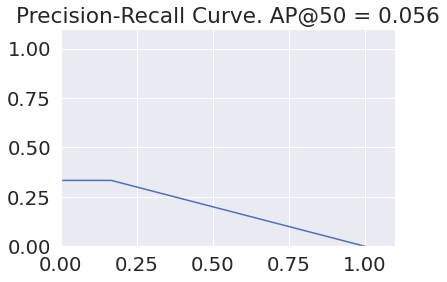

In [22]:
visualize.plot_precision_recall(MODEL_NAME, AP, precisions, recalls)

Processing 1 images
image                    shape: (1280, 1280, 3)       min:    0.00000  max:  225.00000  uint8
molded_images            shape: (1, 1280, 1280, 3)    min: -123.70000  max:  121.10000  float64
image_metas              shape: (1, 18)               min:    0.00000  max: 1280.00000  int64
anchors                  shape: (1, 409200, 4)        min:   -0.28306  max:    1.23302  float32
the actual len of the gt vect is :  3
the actual len of the pred vect is :  3
Average precision of this image :  1.0
The actual mean average precision for the whole images (matterport methode)  1.0
Processing 1 images
image                    shape: (1280, 1280, 3)       min:    0.00000  max:  254.00000  uint8
molded_images            shape: (1, 1280, 1280, 3)    min: -123.70000  max:  150.10000  float64
image_metas              shape: (1, 18)               min:    0.00000  max: 1280.00000  int64
anchors                  shape: (1, 409200, 4)        min:   -0.28306  max:    1.23302  float32
th

the actual len of the gt vect is :  108
the actual len of the pred vect is :  108
Average precision of this image :  0.0
The actual mean average precision for the whole images (matterport methode)  0.3473015891654151
Processing 1 images
image                    shape: (1280, 1280, 3)       min:    0.00000  max:  185.00000  uint8
molded_images            shape: (1, 1280, 1280, 3)    min: -123.70000  max:   81.10000  float64
image_metas              shape: (1, 18)               min:    0.00000  max: 1280.00000  int64
anchors                  shape: (1, 409200, 4)        min:   -0.28306  max:    1.23302  float32
the actual len of the gt vect is :  114
the actual len of the pred vect is :  114
Average precision of this image :  0.7
The actual mean average precision for the whole images (matterport methode)  0.37081481655438747
Processing 1 images
image                    shape: (1280, 1280, 3)       min:    0.00000  max:  220.00000  uint8
molded_images            shape: (1, 1280, 1280, 3) 

Processing 1 images
image                    shape: (1280, 1280, 3)       min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 1280, 1280, 3)    min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 18)               min:    0.00000  max: 1280.00000  int64
anchors                  shape: (1, 409200, 4)        min:   -0.28306  max:    1.23302  float32
the actual len of the gt vect is :  215
the actual len of the pred vect is :  215
Average precision of this image :  0.3333333432674408
The actual mean average precision for the whole images (matterport methode)  0.43202381128711365
Processing 1 images
image                    shape: (1280, 1280, 3)       min:    0.00000  max:  171.00000  uint8
molded_images            shape: (1, 1280, 1280, 3)    min: -123.70000  max:   52.10000  float64
image_metas              shape: (1, 18)               min:    0.00000  max: 1280.00000  int64
anchors                  shape: (1, 409200, 4)        min:   -0

the actual len of the gt vect is :  338
the actual len of the pred vect is :  338
Average precision of this image :  0.32222222288449603
The actual mean average precision for the whole images (matterport methode)  0.400311686909333
Processing 1 images
image                    shape: (1280, 1280, 3)       min:    0.00000  max:  227.00000  uint8
molded_images            shape: (1, 1280, 1280, 3)    min: -123.70000  max:  123.10000  float64
image_metas              shape: (1, 18)               min:    0.00000  max: 1280.00000  int64
anchors                  shape: (1, 409200, 4)        min:   -0.28306  max:    1.23302  float32
the actual len of the gt vect is :  343
the actual len of the pred vect is :  343
Average precision of this image :  0.0
The actual mean average precision for the whole images (matterport methode)  0.3907804562686346
Processing 1 images
image                    shape: (1280, 1280, 3)       min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 1

Processing 1 images
image                    shape: (1280, 1280, 3)       min:    0.00000  max:  219.00000  uint8
molded_images            shape: (1, 1280, 1280, 3)    min: -123.70000  max:  115.10000  float64
image_metas              shape: (1, 18)               min:    0.00000  max: 1280.00000  int64
anchors                  shape: (1, 409200, 4)        min:   -0.28306  max:    1.23302  float32
the actual len of the gt vect is :  496
the actual len of the pred vect is :  496
Average precision of this image :  0.03030303120613098
The actual mean average precision for the whole images (matterport methode)  0.3883477979981816
Processing 1 images
image                    shape: (1280, 1280, 3)       min:    0.00000  max:  215.00000  uint8
molded_images            shape: (1, 1280, 1280, 3)    min: -123.70000  max:  111.10000  float64
image_metas              shape: (1, 18)               min:    0.00000  max: 1280.00000  int64
anchors                  shape: (1, 409200, 4)        min:   -0

the actual len of the gt vect is :  631
the actual len of the pred vect is :  631
Average precision of this image :  0.2977272773330862
The actual mean average precision for the whole images (matterport methode)  0.3954116430888293
Processing 1 images
image                    shape: (1280, 1280, 3)       min:    0.00000  max:  174.00000  uint8
molded_images            shape: (1, 1280, 1280, 3)    min: -123.70000  max:   62.10000  float64
image_metas              shape: (1, 18)               min:    0.00000  max: 1280.00000  int64
anchors                  shape: (1, 409200, 4)        min:   -0.28306  max:    1.23302  float32
the actual len of the gt vect is :  637
the actual len of the pred vect is :  637
Average precision of this image :  0.6666666865348816
The actual mean average precision for the whole images (matterport methode)  0.3993428756025402
Processing 1 images
image                    shape: (1280, 1280, 3)       min:    0.00000  max:  255.00000  uint8
molded_images         

Processing 1 images
image                    shape: (1280, 1280, 3)       min:    0.00000  max:  241.00000  uint8
molded_images            shape: (1, 1280, 1280, 3)    min: -123.70000  max:  117.30000  float64
image_metas              shape: (1, 18)               min:    0.00000  max: 1280.00000  int64
anchors                  shape: (1, 409200, 4)        min:   -0.28306  max:    1.23302  float32
the actual len of the gt vect is :  734
the actual len of the pred vect is :  734
Average precision of this image :  0.4318181818181819
The actual mean average precision for the whole images (matterport methode)  0.3999367065329321
Processing 1 images
image                    shape: (1280, 1280, 3)       min:    0.00000  max:  239.00000  uint8
molded_images            shape: (1, 1280, 1280, 3)    min: -123.70000  max:  115.30000  float64
image_metas              shape: (1, 18)               min:    0.00000  max: 1280.00000  int64
anchors                  shape: (1, 409200, 4)        min:   -0.

the actual len of the gt vect is :  816
the actual len of the pred vect is :  816
Average precision of this image :  1.0
The actual mean average precision for the whole images (matterport methode)  0.4110857186214081
Processing 1 images
image                    shape: (1280, 1280, 3)       min:    0.00000  max:  213.00000  uint8
molded_images            shape: (1, 1280, 1280, 3)    min: -123.70000  max:  109.10000  float64
image_metas              shape: (1, 18)               min:    0.00000  max: 1280.00000  int64
anchors                  shape: (1, 409200, 4)        min:   -0.28306  max:    1.23302  float32
the actual len of the gt vect is :  818
the actual len of the pred vect is :  818
Average precision of this image :  0.0
The actual mean average precision for the whole images (matterport methode)  0.40680357571910175



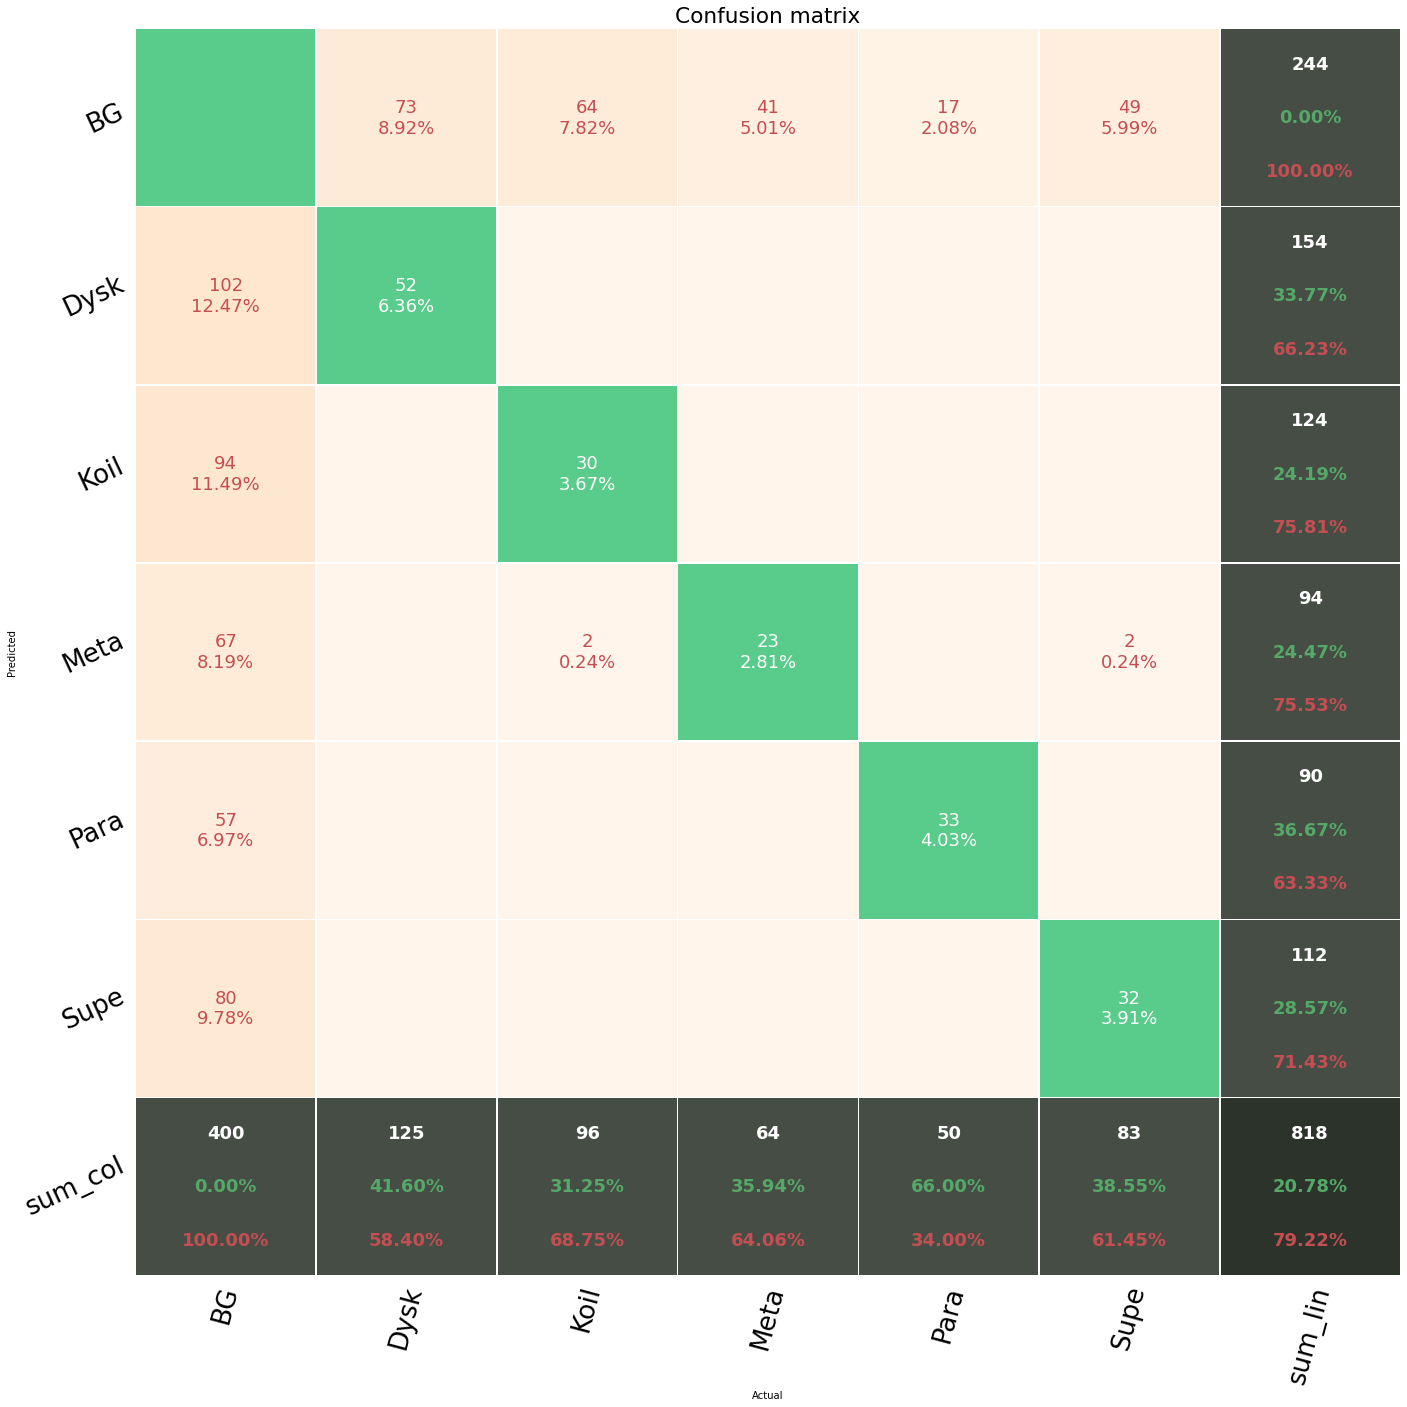

In [19]:
# an example of plotting confusion matrix.
# the first step consists of computing ground-truth and prediction vectors for all images.
# using these vectors, the plot_confusion_matrix_from_data function plots the CM and computes tps fps and fns
import pandas as pd
import numpy as np
import os 

#ground-truth and predictions lists
gt_tot = np.array([])
pred_tot = np.array([])
#mAP list
mAP_ = []


for id in tnrange(len(image_ids), desc = "Processing images in dataset..."):
    # Load image and ground truth data
    image, image_meta, gt_class_id, gt_bbox, gt_mask =\
        modellib.load_image_gt(dataset_val, EvalConfig(),
                               image_ids[id], use_mini_mask=False)

    # Run the model
    results = model.detect([image], verbose=1)
    r = results[0]
    
    #compute gt_tot and pred_tot
    gt, pred = utils.gt_pred_lists(gt_class_id, gt_bbox, r['class_ids'], r['rois'])
    gt_tot = np.append(gt_tot, gt)
    pred_tot = np.append(pred_tot, pred)
    
    #precision_, recall_, AP_ 
    AP_, precision_, recall_, overlap_ = utils.compute_ap(gt_bbox, gt_class_id, gt_mask,
                                          r['rois'], r['class_ids'], r['scores'], r['masks'])
    #check if the vectors len are equal
    print("the actual len of the gt vect is : ", len(gt_tot))
    print("the actual len of the pred vect is : ", len(pred_tot))
    
    mAP_.append(AP_)
    print("Average precision of this image : ",AP_)
    print("The actual mean average precision for the whole images (matterport methode) ", sum(mAP_)/len(mAP_))
   # print("Ground truth object : "+dataset_val.class_names[gt])
   # print("Predicted object : "+dataset_val.class_names[pred])


#print("ground truth list : ",gt_tot)
#print("predicted list : ",pred_tot)

tp,fp,fn, dm =utils.plot_confusion_matrix_from_data(MODEL_NAME, class_names, gt_tot,pred_tot,fz=18, figsize=(20,20), lw=0.5)

In [20]:
print("tp for each class :",tp)
print("fp for each class :",fp)
print("fn for each class :",fn)

#eliminate the background class (class A) from tps fns and fns lists since it doesn't concern us anymore : 
del tp[0]
del fp[0]
del fn[0]


print("\n########################\n")
print("tp for each class :",tp)
print("fp for each class :",fp)
print("fn for each class :",fn)

tp for each class : [0, 52, 30, 23, 33, 32]
fp for each class : [244, 102, 94, 71, 57, 80]
fn for each class : [400, 73, 66, 41, 17, 51]

########################

tp for each class : [52, 30, 23, 33, 32]
fp for each class : [102, 94, 71, 57, 80]
fn for each class : [73, 66, 41, 17, 51]


In [ ]:
ACC = sum(tp)/sum(tp+tp+fn)

In [ ]:
ACC